## Multivariate analyisis of the volatile compounds annotated

### Import dependencies

In [2]:
import os
os.chdir('..')  #cd to coffeeleafinfuses folder

import pandas as pd
import numpy as np
from pathlib import Path
from scipy.spatial.distance import euclidean
from scipy.stats import f_oneway
from sklearn.decomposition import PCA
from skbio.stats.distance import permanova 
from skbio.stats.distance import DistanceMatrix 
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
import seaborn as sns
from typing import Optional, Union, Iterable, Dict
from src.utils import load_config

### Data import


In [3]:
#load config file
config = load_config(path='config/config.yaml', section='gc-ms')

hot_infuses = Path(config['ftable_hot'])
cold_infuses = Path(config['ftable_cold'])
metadata = Path(config['metadata'])

# load data
hot_scaled = pd.read_csv(hot_infuses, index_col=0)
cold_scaled = pd.read_csv(cold_infuses, index_col=0)
        
# group mapping
meta_df = pd.read_csv(metadata, sep='\t', index_col='ATTRIBUTE_Sample')
grp_map = meta_df['ATTRIBUTE_Group']
        
print(f" Data loaded: HOT {hot_scaled.shape}, COLD {cold_scaled.shape}")
print(f"Metadata loaded for {len(grp_map)} samples")

 Data loaded: HOT (15, 73), COLD (15, 58)
Metadata loaded for 30 samples


### PERMANOVA and PCA


PCA: Hot Infuses | Explained Var: 65.4%

--- PERMDISP Test: Hot Infuses (PC space) ---
F-statistic: 2.1843, p-value: 0.1443

--- PERMANOVA Test: Hot Infuses (PC space) ---
method name                PERMANOVA
test statistic name         pseudo-F
sample size                       15
number of groups                   5
test statistic            258.918839
p-value                        0.001
number of permutations           999
Name: PERMANOVA results, dtype: object

PCA: Cold Infuses | Explained Var: 82.0%

--- PERMDISP Test: Cold Infuses (PC space) ---
F-statistic: 4.4079, p-value: 0.0260

--- PERMANOVA Test: Cold Infuses (PC space) ---
method name                PERMANOVA
test statistic name         pseudo-F
sample size                       15
number of groups                   5
test statistic            298.814472
p-value                        0.001
number of permutations           999
Name: PERMANOVA results, dtype: object

PCA: Cold Infuses | Explained Var: 82.0%

--- PERMDISP

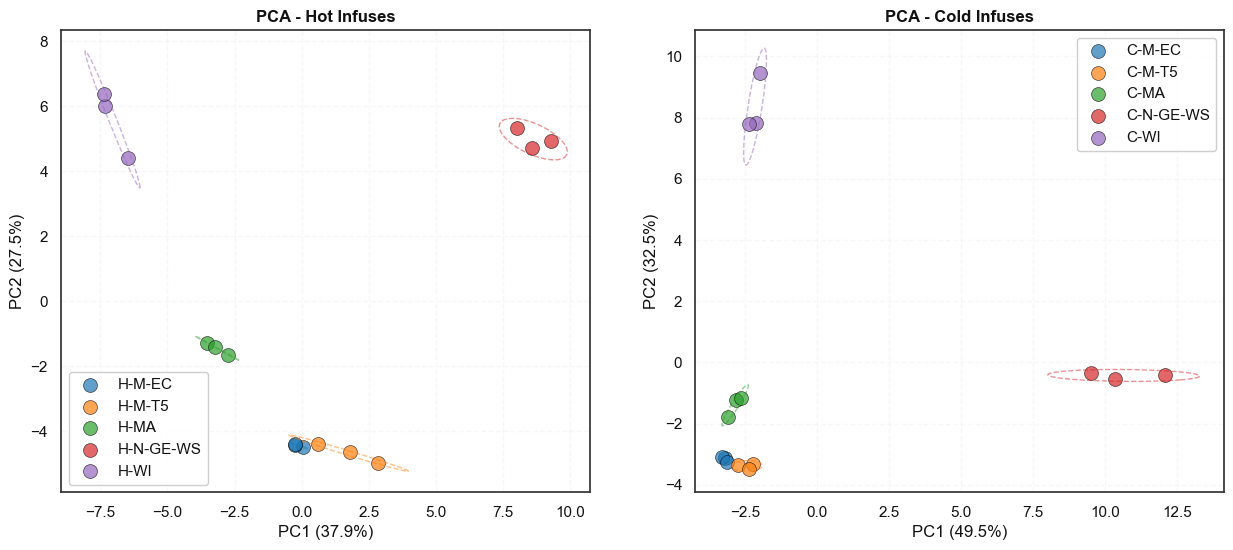

Saved: results\Volatile_analysis\PCA\pca_biplots.png
Saved: results\Volatile_analysis\PCA\pca_biplots.svg
Saved: results\Volatile_analysis\PCA\pca_biplots.svg


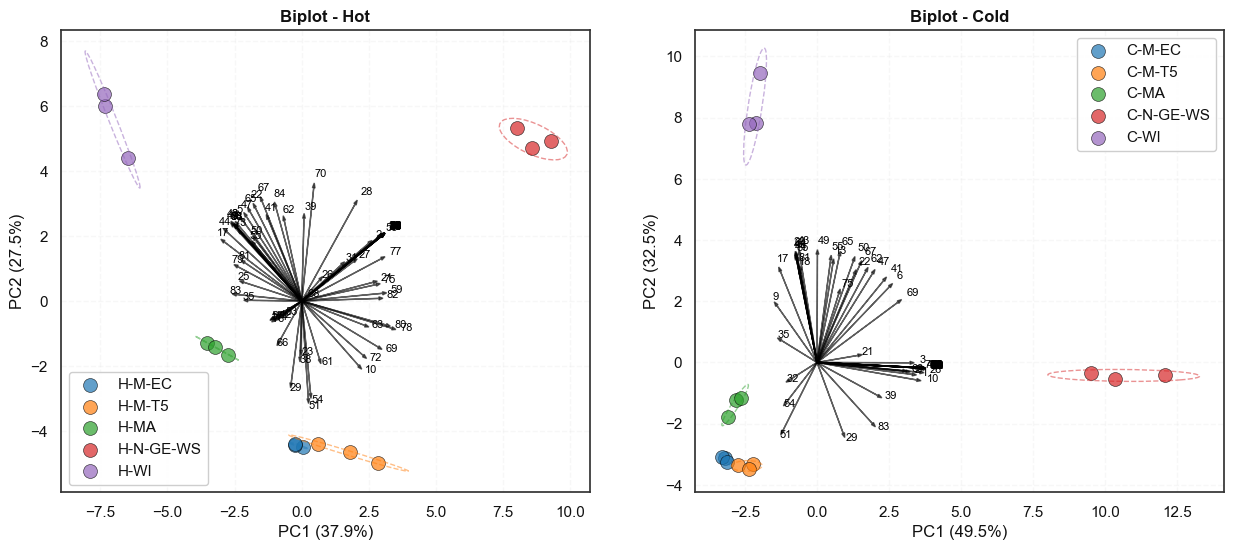

In [3]:
# ===========================================================================
# CONFIGURATION
# ============================================================================

OUTPUT_DIR = Path("results/Volatile_analysis/PCA")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Plot styling
sns.set_style('white') 
sns.set_context('notebook')

plt.rcParams.update({
    'figure.facecolor': '#ffffff',
    'axes.facecolor': '#ffffff',
    'axes.edgecolor': '#333333',
    'axes.labelcolor': '#111111',
    'xtick.color': '#111111',
    'ytick.color': '#111111',
    'grid.color': '#e6e6e6',
    'grid.linestyle': '--',
    'grid.alpha': 0.8,
    'text.color': '#111111',
    'legend.frameon': True,
    'legend.framealpha': 0.95,
    'legend.facecolor': '#ffffff',
    'legend.edgecolor': '#cccccc'
})

COLORS = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
FIGURE_DPI = 600
FIGURE_FORMAT = ['png', 'svg']
PCA_COMPONENTS = 2
PERMANOVA_PERMUTATIONS = 999
PERMDISP_ALPHA = 0.05
CONFIDENCE_LEVEL = 2.0 

# ============================================================================
# UTILITY FUNCTIONS
# ============================================================================

def confidence_ellipse(mean, cov, ax, n_std=2.0, **kwargs):
    pearson = cov[0, 1] / np.sqrt(cov[0, 0] * cov[1, 1])
    ell_radius_x = np.sqrt(1 + pearson)
    ell_radius_y = np.sqrt(1 - pearson)
    ellipse = Ellipse((0, 0), width=ell_radius_x * 2, height=ell_radius_y * 2, **kwargs)
    scale_x = np.sqrt(cov[0, 0]) * n_std
    scale_y = np.sqrt(cov[1, 1]) * n_std
    transf = matplotlib.transforms.Affine2D().rotate_deg(45).scale(scale_x, scale_y).translate(mean[0], mean[1])
    ellipse.set_transform(transf + ax.transData)
    return ax.add_patch(ellipse)

def save_figure(fig, prefix, formats=FIGURE_FORMAT, dpi=FIGURE_DPI):
    for fmt in formats:
        filepath = OUTPUT_DIR / f"{prefix}.{fmt}"
        fig.savefig(filepath, dpi=dpi, bbox_inches='tight')
        print(f"Saved: {filepath}")

# ============================================================================
# STATISTICAL TESTS
# ============================================================================

def run_permdisp(df: pd.DataFrame, group_series: pd.Series, title: str):
    common_ids = df.index.intersection(group_series.index)
    df = df.loc[common_ids]
    group_series = group_series.loc[common_ids]

    print(f"\n--- PERMDISP Test: {title} ---")
    
    # Calculate centroids and distances
    group_centroids = {}
    for group in group_series.unique():
        members = df[group_series == group]
        group_centroids[group] = members.mean().values

    distances_to_centroid = []
    group_labels = []
    for sample_id in df.index:
        group = group_series[sample_id]
        dist = euclidean(df.loc[sample_id].values, group_centroids[group])
        distances_to_centroid.append(dist)
        group_labels.append(group)

    dist_by_group = pd.DataFrame({'Group': group_labels, 'Distance': distances_to_centroid})
    grouped_distances = [g['Distance'].values for _, g in dist_by_group.groupby('Group')]
    
    f_stat, p_val = f_oneway(*grouped_distances)
    print(f"F-statistic: {f_stat:.4f}, p-value: {p_val:.4f}")
    
    return {'F-statistic': f_stat, 'p-value': p_val}

def run_permanova(df: pd.DataFrame, group_series: pd.Series, title: str, save_prefix: str):
    common_ids = df.index.intersection(group_series.index)
    df = df.loc[common_ids]
    group_series = group_series.loc[common_ids]

    print(f"\n--- PERMANOVA Test: {title} ---")
    try:
        dist_matrix = DistanceMatrix.from_iterable(df.values, metric=euclidean, keys=df.index)
        result = permanova(dist_matrix, group_series, permutations=PERMANOVA_PERMUTATIONS)
        print(result)
        
        with open(OUTPUT_DIR / f"{save_prefix}_permanova.txt", 'w') as f:
            f.write(f"PERMANOVA Result: {title}\n{'='*70}\n{str(result)}")
        return result
    except Exception as e:
        print(f"[PERMANOVA ERROR] {e}")
        return None

# ============================================================================
# PCA & PLOTTING
# ============================================================================

def run_pca_analysis(df_scaled: pd.DataFrame, group_series: pd.Series, title: str, save_prefix: str):
    # Ensure index alignment
    common_ids = df_scaled.index.intersection(group_series.index)
    df_scaled = df_scaled.loc[common_ids]
    group_series = group_series.loc[common_ids]

    pca = PCA(n_components=PCA_COMPONENTS)
    pcs = pca.fit_transform(df_scaled.values)
    
    pca_df = pd.DataFrame(pcs[:, :PCA_COMPONENTS], index=df_scaled.index, columns=[f'PC{i+1}' for i in range(PCA_COMPONENTS)])

    print(f"\nPCA: {title} | Explained Var: {pca.explained_variance_ratio_[:2].sum():.1%}")
    
    run_permdisp(pca_df, group_series, f'{title} (PC space)')
    run_permanova(pca_df, group_series, f'{title} (PC space)', save_prefix)

    return pca, pca_df, df_scaled

def plot_pca_scores(pca, pca_df, group_series, title, ax):
    groups = pca_df.index.map(group_series)
    unique_groups = np.unique(groups)
    
    for i, group in enumerate(unique_groups):
        mask = groups == group
        color = COLORS[i % len(COLORS)]
        ax.scatter(pca_df.loc[mask, 'PC1'], pca_df.loc[mask, 'PC2'], label=group, s=100, alpha=0.7, color=color, edgecolors='k', linewidth=0.5)
        
        # Confidence Ellipse
        if np.sum(mask) > 2: # Need at least 3 points for covariance
            mean = pca_df.loc[mask, ['PC1', 'PC2']].mean().values
            cov = pca_df.loc[mask, ['PC1', 'PC2']].cov().values
            confidence_ellipse(mean, cov, ax, n_std=CONFIDENCE_LEVEL, edgecolor=color, facecolor='none', linestyle='--', alpha=0.5)

    ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
    ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
    ax.set_title(title, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)

def plot_biplot(pca, df_scaled, pca_df, group_series, title, ax):
    # Standard score plot first
    plot_pca_scores(pca, pca_df, group_series, title, ax)
    
    # Loadings
    loadings = pca.components_[:2, :].T
    loading_matrix = loadings * np.sqrt(pca.explained_variance_[:2])
    scale_factor = 3.5 # Adjust this if arrows are too small/big

    # Select top contributing features 
    for i, feature in enumerate(df_scaled.columns):
        ax.arrow(0, 0, loading_matrix[i, 0]*scale_factor, loading_matrix[i, 1]*scale_factor, 
                 head_width=0.1, fc='black', ec='black', alpha=0.6, width=0.005)
        ax.text(loading_matrix[i, 0]*scale_factor*1.1, loading_matrix[i, 1]*scale_factor*1.1, 
                feature, color='black', fontsize=8)

# ============================================================================
# MAIN EXECUTION
# ============================================================================

def main(hot_scaled, cold_scaled, grp_map):
    # 1. Run PCA Analysis
    pca_hot, scores_hot, hot_data = run_pca_analysis(hot_scaled, grp_map, 'Hot Infuses', 'hot')
    pca_cold, scores_cold, cold_data = run_pca_analysis(cold_scaled, grp_map, 'Cold Infuses', 'cold')

    # 2. Plot Scores
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    plot_pca_scores(pca_hot, scores_hot, grp_map, 'PCA - Hot Infuses', axes[0])
    plot_pca_scores(pca_cold, scores_cold, grp_map, 'PCA - Cold Infuses', axes[1])
    save_figure(fig, 'pca_scores')
    plt.show()

    # 3. Plot Biplots
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    plot_biplot(pca_hot, hot_data, scores_hot, grp_map, 'Biplot - Hot', axes[0])
    plot_biplot(pca_cold, cold_data, scores_cold, grp_map, 'Biplot - Cold', axes[1])
    save_figure(fig, 'pca_biplots')
    plt.show()

main(hot_scaled, cold_scaled, grp_map)

### Heatmap

In [ ]:
def create_heatmap(df_scaled: pd.DataFrame, group_series: pd.Series, 
                   title: str, save_prefix: str, top_n: int = None,
                   figsize: tuple = (12, 10), compound_names: pd.Series = None,
                   group_palette: Optional[Union[str, Iterable[str], Dict[str, str]]] = None):
    """
    Create clustered heatmap with hierarchical clustering.
    """
    
    # Align indices
    common_ids = df_scaled.index.intersection(group_series.index)
    df_scaled = df_scaled.loc[common_ids]
    group_series = group_series.loc[common_ids]
    
    # Filter: keep only features with at least one non-zero value
    df_nonzero = df_scaled.loc[:, (df_scaled != 0).any(axis=0)]
    
    # Select features
    feature_variance = df_nonzero.var(axis=0)
    if top_n is None:
        df_top = df_nonzero.copy()
        features_text = f"all features with non-zero values ({df_nonzero.shape[1]})"
    else:
        top_features = feature_variance.nlargest(top_n).index
        df_top = df_nonzero[top_features].copy()
        features_text = f"top {top_n} most variable features"
    
    print(f"\n{'='*70}")
    print(f"Heatmap analysis: {title}")
    print(f"{'='*70}")
    print(f"Total features (original): {df_scaled.shape[1]}")
    print(f"Features with non-zero values: {df_nonzero.shape[1]}")
    print(f"Selected: {features_text}")
    print(f"Samples: {df_top.shape[0]}")
    
    # Prepare data for heatmap (transpose: features as rows, samples as columns)
    df_heatmap = df_top.T
    
    # Map feature IDs to compound names if provided
    if compound_names is not None:
        df_heatmap.index = df_heatmap.index.map(
            lambda x: compound_names.get(x, x) if x in compound_names.index else x,
        )
    
    # Create color mapping for groups
    groups = list(group_series.unique())   
    n_groups = len(groups)

    # Build palette according to group_palette or fallback to global COLORS (used by PCA)
    from itertools import cycle
    if group_palette is None:
        palette_list = list(COLORS)  # use the same COLORS used in PCA
    elif isinstance(group_palette, dict):
        palette_list = [group_palette.get(g, "#BBBBBB") for g in groups]
    elif isinstance(group_palette, str):
        palette_list = sns.color_palette(group_palette, n_colors=n_groups)
    else:
        palette_list = list(group_palette)

    # If provided list is shorter than number of groups, cycle it to fill
    if len(palette_list) < n_groups:
        cyc = cycle(palette_list)
        palette_colors = [next(cyc) for _ in range(n_groups)]
    else:
        palette_colors = palette_list[:n_groups]

    group_colors = {group: palette_colors[i] for i, group in enumerate(groups)}
    
    # Create column colors (sample annotation)
    col_colors = group_series.map(group_colors)
    
    # Create clustermap
    sns.set_theme(style="white", font_scale=0.8)

    g = sns.clustermap(
        df_heatmap,
        method='ward',           # Hierarchical clustering method
        metric='euclidean',      # Distance metric
        cmap='vlag',             # Color palette (diverging)
        center=0,                # Center colormap at 0
        col_colors=col_colors,   # Sample group colors
        figsize=figsize,
        cbar_kws = {'label': 'Scaled abundance'},
        dendrogram_ratio=0.1,
        colors_ratio=0.03,
        linewidths=0,
        xticklabels=True,
        yticklabels=True
    )

    # Adjust labels
    g.ax_heatmap.set_xlabel('Samples', fontsize=10)
    g.ax_heatmap.set_ylabel('Metabolites', fontsize=10)
    g.ax_heatmap.set_title(title, fontsize=12, pad=20)
    
    # Rotate x-axis labels
    plt.setp(g.ax_heatmap.xaxis.get_majorticklabels(), rotation=90, fontsize=7)
    plt.setp(g.ax_heatmap.yaxis.get_majorticklabels(), fontsize=7)
    
    # Add legend for groups
    handles = [plt.Line2D([0], [0], marker='o', color='w', 
                         markerfacecolor=color, markersize=10, label=group)
              for group, color in group_colors.items()]
    g.ax_heatmap.legend(handles=handles, title='Groups', 
                       bbox_to_anchor=(1.30, 1), loc='upper left',
                       frameon=True, fontsize=8)
    
    # Save figure
    os.makedirs("results/Volatile_analysis/Heatmap", exist_ok=True)
    suffix = f"_top{top_n}" if top_n else "_all"
    g.fig.savefig(f"results/Volatile_analysis/Heatmap/{save_prefix}_heatmap.png", 
                  dpi=300, bbox_inches='tight')
    g.fig.savefig(f"results/Volatile_analysis/Heatmap/{save_prefix}_heatmap.svg", 
                  bbox_inches='tight')
    
    print(f"Heatmap saved: results/Volatile_analysis/Heatmap/{save_prefix}_heatmap.*")
    
    plt.show()
    
    return g, df_top

# === MAIN EXECUTION ==========================================================

if __name__ == '__main__':
    
    print("\n" + "="*70)
    print("HEATMAP ANALYSIS")
    print("="*70)
    
    # Ensure `compound_names` is defined (allow running this cell standalone)
    if 'compound_names' not in globals():
        compound_names = None

    # Hot extraction - All features
    print("\n Hot infuses")
    g_hot, top_hot = create_heatmap(
        hot_scaled, 
        grp_map,
        '',
        'hot',
        top_n=None,
        figsize=(5, 10),
        compound_names=compound_names
    )
    
    # Cold extraction - All features
    print("\n Cold infuses")
    g_cold, top_cold = create_heatmap(
        cold_scaled,
        grp_map,
        '',
        'cold',
        top_n=None,
        figsize=(5, 10),
        compound_names=compound_names 
    )

    print("Heatmap analysis complete")


### Supplementary figures


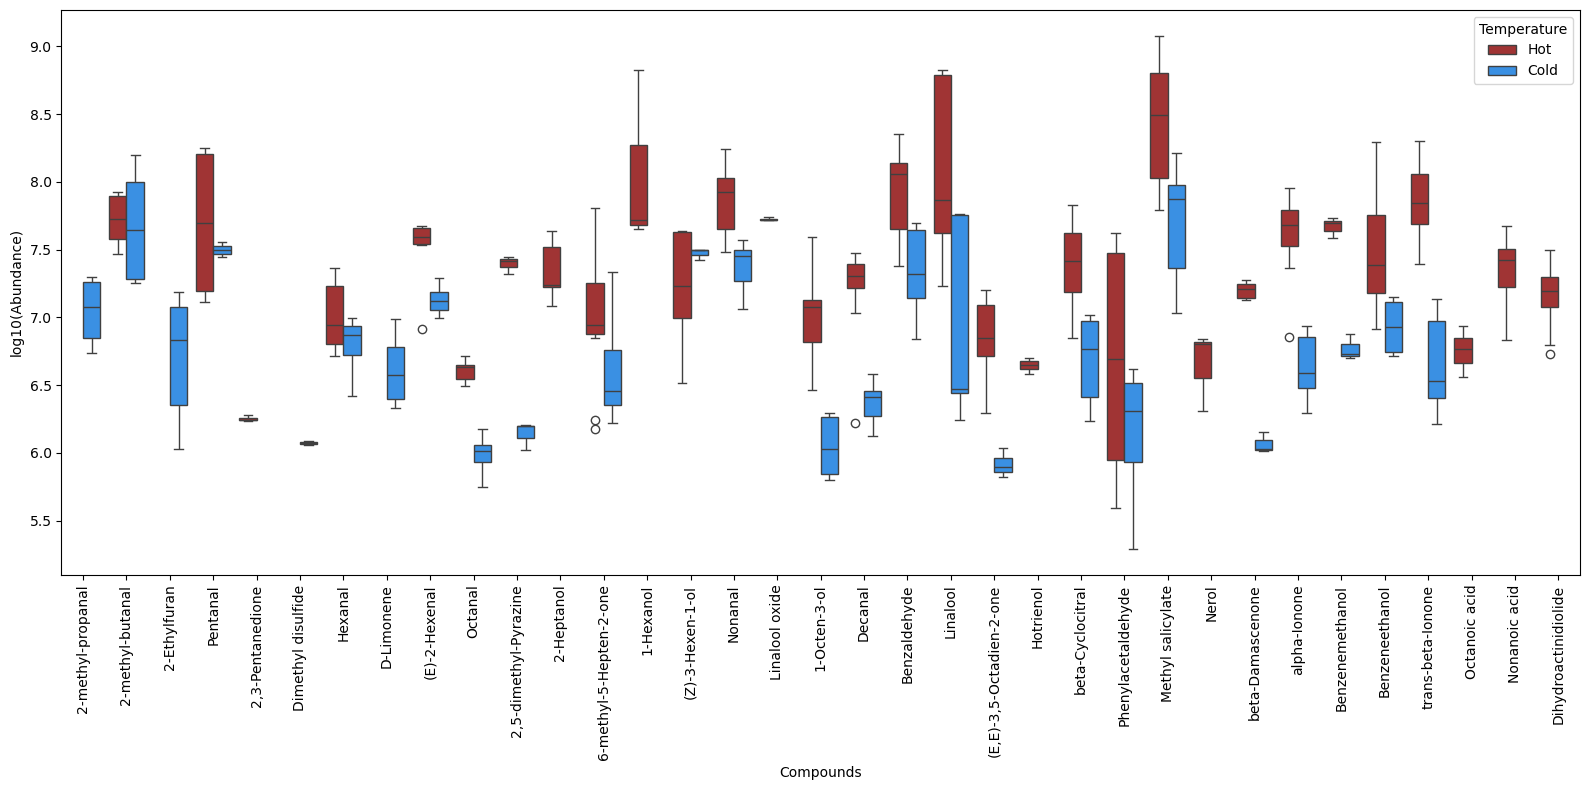

Generating Hot Infusion Plots...


c:\Users\david\miniconda3\envs\coffeeleafinfuses\Lib\site-packages\seaborn\axisgrid.py:854: FutureWarning: Use "auto" to set automatic grayscale colors. From v0.14.0, "gray" will default to matplotlib's definition.
  func(*plot_args, **plot_kwargs)
c:\Users\david\miniconda3\envs\coffeeleafinfuses\Lib\site-packages\seaborn\axisgrid.py:854: FutureWarning: Use "auto" to set automatic grayscale colors. From v0.14.0, "gray" will default to matplotlib's definition.
  func(*plot_args, **plot_kwargs)
c:\Users\david\miniconda3\envs\coffeeleafinfuses\Lib\site-packages\seaborn\axisgrid.py:854: FutureWarning: Use "auto" to set automatic grayscale colors. From v0.14.0, "gray" will default to matplotlib's definition.
  func(*plot_args, **plot_kwargs)
c:\Users\david\miniconda3\envs\coffeeleafinfuses\Lib\site-packages\seaborn\axisgrid.py:854: FutureWarning: Use "auto" to set automatic grayscale colors. From v0.14.0, "gray" will default to matplotlib's definition.
  func(*plot_args, **plot_kwargs)
c:\U

Generating Cold Infusion Plots...


c:\Users\david\miniconda3\envs\coffeeleafinfuses\Lib\site-packages\seaborn\axisgrid.py:854: FutureWarning: Use "auto" to set automatic grayscale colors. From v0.14.0, "gray" will default to matplotlib's definition.
  func(*plot_args, **plot_kwargs)
c:\Users\david\miniconda3\envs\coffeeleafinfuses\Lib\site-packages\seaborn\axisgrid.py:854: FutureWarning: Use "auto" to set automatic grayscale colors. From v0.14.0, "gray" will default to matplotlib's definition.
  func(*plot_args, **plot_kwargs)
c:\Users\david\miniconda3\envs\coffeeleafinfuses\Lib\site-packages\seaborn\axisgrid.py:854: FutureWarning: Use "auto" to set automatic grayscale colors. From v0.14.0, "gray" will default to matplotlib's definition.
  func(*plot_args, **plot_kwargs)
c:\Users\david\miniconda3\envs\coffeeleafinfuses\Lib\site-packages\seaborn\axisgrid.py:854: FutureWarning: Use "auto" to set automatic grayscale colors. From v0.14.0, "gray" will default to matplotlib's definition.
  func(*plot_args, **plot_kwargs)
c:\U

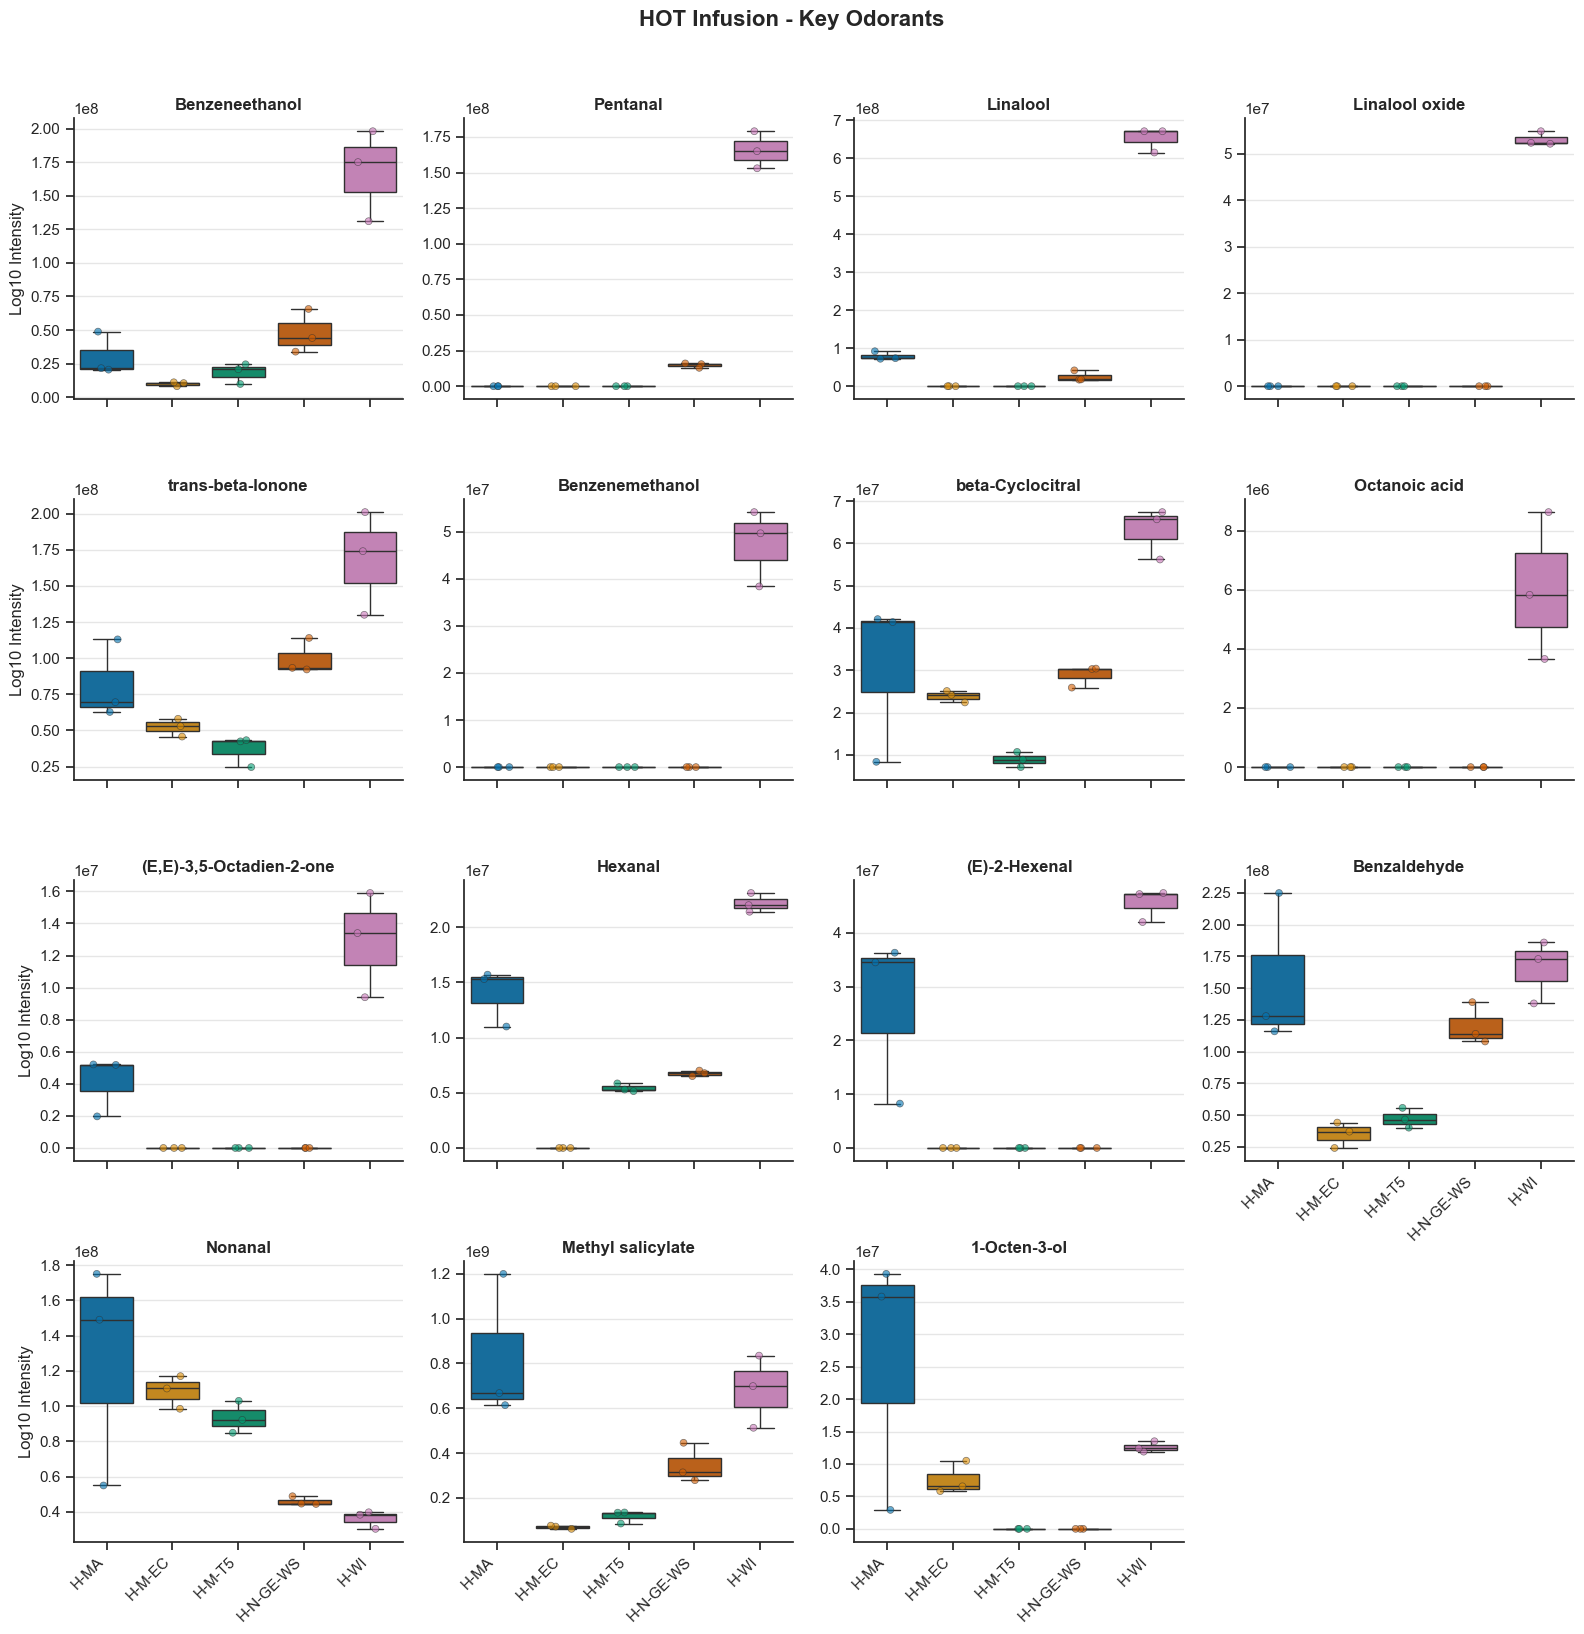

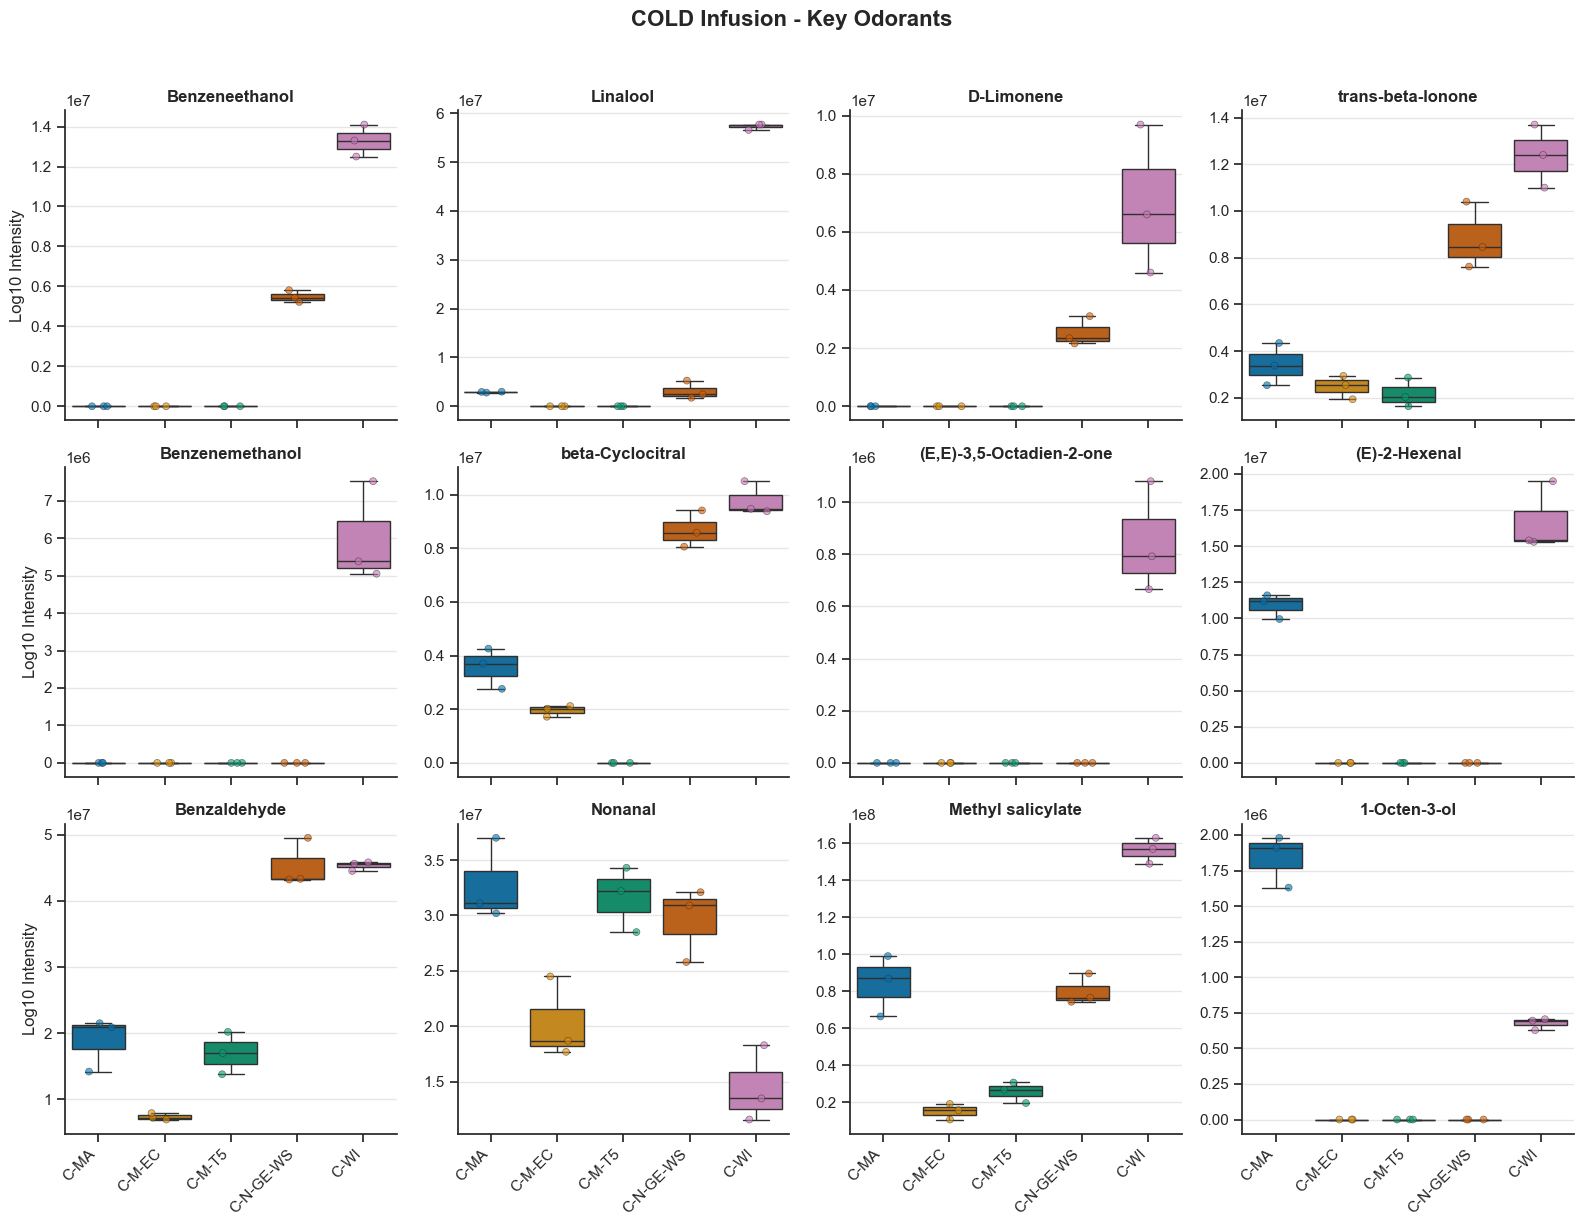

In [4]:
#load config file
config = load_config(path='config/config.yaml', section='gc-ms')
key_odorants = Path(config['key_odorants'])
metadata = Path(config['metadata'])

# load data
df = pd.read_csv(key_odorants, index_col=0)  

# group mapping
meta_df = pd.read_csv(metadata, sep='\t', index_col='ATTRIBUTE_Sample')
grp_map = meta_df['ATTRIBUTE_Group'] # group mapping
tmp_map = meta_df['ATTRIBUTE_Extraction'] #temperature mapping H or C

# Apply Mappings
df['Group'] = df.index.map(grp_map)
df['Temperature'] = df.index.map(tmp_map)

# Reset index to make 'Samples' a dedicated column for plotting
df = df.reset_index()
# Rename the old index column to 'Samples' if it isn't named correctly
if 'Samples' not in df.columns:
    df.rename(columns={'index': 'Samples'}, inplace=True)

# Prepare Data for Plotting 
df_long = df.melt(
    id_vars=['Samples', 'Temperature', 'Group'], 
    var_name='Compounds', 
    value_name='Intensity'
)

# Log-transform
df_long['Intensity'] = df_long['Intensity'].replace(0, np.nan)
df_long['Intensity_log'] = np.log10(df_long['Intensity'])

temp_colors = {
    'Hot': 'firebrick',   # or 'red'
    'Cold': 'dodgerblue'   # or 'blue'
}

# Boxplot of Key Odorants by Temperature

plt.figure(figsize=(16, 8))
sns.boxplot(
    data=df_long, 
    x='Compounds', 
    y='Intensity_log', 
    hue='Temperature',
    palette=temp_colors
)

plt.xticks(rotation=90)
plt.ylabel('log10(Abundance)')
plt.xlabel('Compounds')
plt.tight_layout()
plt.show()



# ============================================================================
# 2. DEFINE PLOTTING FUNCTION
# ============================================================================
def plot_faceted_molecules(data, molecule_list, dataset_name, 
                           group_col='Group', n_cols=4, palette=None):
    """
    Generates faceted boxplots for specific molecules from a wide dataframe.
    """
    
    # 1. Validate Molecules
    # Filter list to only include molecules actually present in the dataframe
    valid_molecules = [m for m in molecule_list if m in data.columns]
    missing_molecules = set(molecule_list) - set(valid_molecules)
    
    if missing_molecules:
        print(f"[{dataset_name}] Warning: Missing molecules skipped: {missing_molecules}")
    
    if not valid_molecules:
        print(f"[{dataset_name}] No valid molecules to plot.")
        return None

    # 2. Prepare Data (Subset & Melt)
    # We only keep the Group column and the specific molecules
    subset = data[[group_col] + valid_molecules].copy()
    
    # Melt to Long Format for Seaborn
    plot_data = subset.melt(
        id_vars=[group_col], 
        value_vars=valid_molecules,
        var_name='Molecule', 
        value_name='Log Abundance'
    )

    # 3. Define Colors
    if palette is None:
        unique_groups = plot_data[group_col].unique()
        # Default accessible palette
        default_colors = sns.color_palette("colorblind", len(unique_groups))
        palette = dict(zip(unique_groups, default_colors))

    # 4. Create Faceted Plot
    # context='talk' scales elements up slightly for better readability
    sns.set_theme(style="ticks", rc={'axes.grid': True, 'grid.color': '.9'})
    
    g = sns.catplot(
        data=plot_data, 
        x=group_col, 
        y='Log Abundance', 
        hue=group_col,
        col='Molecule', 
        col_wrap=n_cols,
        kind='box', 
        palette=palette,
        sharey=False,
        height=4, 
        aspect=1,
        dodge=False,
        fliersize=0
    )

    # 5. Add Jitter Points (Raw data overlay)
    g.map_dataframe(
        sns.stripplot, 
        x=group_col, 
        y='Log Abundance', 
        hue=group_col,
        palette=palette,
        jitter=0.2, 
        alpha=0.6, 
        edgecolor='gray', 
        linewidth=0.5,
        legend=False
    )

    # 6. Styling
    g.fig.suptitle(f"{dataset_name} - Key Odorants", fontsize=16, fontweight='bold', y=1.02)
    g.set_titles("{col_name}", fontweight='bold')
    g.set_axis_labels("", "Log10 Intensity")
    
    # Rotate x-axis labels if they are long
    for ax in g.axes.flat:
        plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

    plt.tight_layout()
    return g

# ============================================================================
# 3. EXECUTION PARAMETERS
# ============================================================================

# Define specific lists of metabolites
hot_molecules = [
  "Benzeneethanol", "Pentanal", "Linalool", "Linalool oxide", 
  "trans-beta-Ionone", "Benzenemethanol", "beta-Cyclocitral",
  "Octanoic acid", "(E,E)-3,5-Octadien-2-one", "Hexanal", 
  "(E)-2-Hexenal", "Benzaldehyde", "Nonanal", "Methyl salicylate", "1-Octen-3-ol"
]

cold_molecules = [
  "Benzeneethanol", "Linalool", "D-Limonene", "trans-beta-Ionone",
  "Benzenemethanol", "beta-Cyclocitral", "(E,E)-3,5-Octadien-2-one",
  "(E)-2-Hexenal", "Benzaldehyde", "Nonanal", "Methyl salicylate", "1-Octen-3-ol"
]


# ============================================================================
# 4. GENERATE PLOTS
# ============================================================================

df_hot = df[df['Temperature'] == 'Hot']
df_cold = df[df['Temperature'] == 'Cold']

# --- PLOT HOT INFUSION ---
if not df_hot.empty:
    print("Generating Hot Infusion Plots...")
    g_hot = plot_faceted_molecules(
        df_hot, 
        hot_molecules, 
        dataset_name="HOT Infusion", 
        group_col='Group',
        palette=None 
    )

# --- PLOT COLD INFUSION ---
if not df_cold.empty:
    print("Generating Cold Infusion Plots...")
    g_cold = plot_faceted_molecules(
        df_cold, 
        cold_molecules, 
        dataset_name="COLD Infusion", 
        group_col='Group',
        palette=None
    )